# 01 — Data Loading & Inspection

**Goal:** Load both raw data sources, get a feel for their structure, and flag anything that'll need fixing in the cleaning notebook.

We have two sources:
1. **National time series** — monthly England-wide totals from August 2010 to present (one XLS, Activity sheet)
2. **Quarterly by-provider** — trust-level data for each quarter, 2019-20 through 2024-25 (24 XLS files)

This notebook is read-only — no data is modified or written.

In [10]:
import pandas as pd
import numpy as np
import glob
import os
import warnings

# xlrd emits warnings about formula references in chart sheets — safe to suppress
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:,.0f}".format)

---
## Part 1 — National Time Series

This file contains monthly national-level A&E data. The XLS has 6 sheets; we want **Activity** for attendance and admission counts, and **Performance** for the 4-hour metric.

The first 13 rows are metadata (title, summary, contact info). Row 13 (0-indexed) is the real column header.

In [11]:
TS_PATH = "../data/raw/time_series/Monthly-AE-Time-Series-April-2026.xls"

# What sheets exist?
xl = pd.ExcelFile(TS_PATH, engine="xlrd")
print("Sheets:", xl.sheet_names)

Sheets: ['Activity', 'Performance', 'Booking', 'Notes', 'Chart Data', 'Charts']


In [12]:
# Load Activity sheet — skiprows=13 skips the metadata block
ts_raw = pd.read_excel(
    TS_PATH,
    sheet_name="Activity",
    engine="xlrd",
    skiprows=13
)

print(f"Shape: {ts_raw.shape}")
ts_raw.head(3)

Shape: (189, 18)


,Unnamed: 0,Period,Type 1 Departments - Major A&E,Type 2 Departments - Single Specialty,Type 3 Departments - Other A&E/Minor Injury Unit,Total Attendances,Emergency Admissions via Type 1 A&E,Emergency Admissions via Type 2 A&E,Emergency Admissions via Type 3 and 4 A&E,Total Emergency Admissions via A&E,Other Emergency Admissions (i.e not via A&E),Total Emergency Admissions,Number of patients spending >4 hours from decision to admit to admission,Number of patients spending >12 hours from decision to admit to admission,Unnamed: 14,Operational standard (Performance),Unnamed: 16,1
0,NaN,2010-08-01,"1,138,652","54,371","559,358","1,752,381","287,438","5,367","8,081","300,886","124,816","425,702","3,697",1,NaN,1,NaN,NaN
1,NaN,2010-09-01,"1,150,728","55,181","550,359","1,756,268","293,991","5,543","3,673","303,207","121,693","424,900","5,907",0,NaN,1,NaN,NaN
2,NaN,2010-10-01,"1,163,143","54,961","583,244","1,801,348","303,452","5,485","2,560","311,497","124,718","436,215","6,932",0,NaN,1,NaN,NaN


In [13]:
# Column inventory
print("All columns:")
for i, col in enumerate(ts_raw.columns):
    print(f"  [{i:2d}] {col}")

All columns:
  [ 0] Unnamed: 0
  [ 1] Period
  [ 2] Type 1 Departments - Major A&E
  [ 3] Type 2 Departments - Single Specialty
  [ 4] Type 3 Departments - Other A&E/Minor Injury Unit
  [ 5] Total Attendances
  [ 6] Emergency Admissions via Type 1 A&E
  [ 7] Emergency Admissions via Type 2 A&E
  [ 8] Emergency Admissions via Type 3 and 4 A&E
  [ 9] Total Emergency Admissions via A&E
  [10] Other Emergency Admissions (i.e not via A&E)
  [11] Total Emergency Admissions
  [12] Number of patients spending >4 hours from decision to admit to admission
  [13] Number of patients spending >12 hours from decision to admit to admission
  [14] Unnamed: 14
  [15] Operational standard (Performance)
  [16] Unnamed: 16
  [17] 0.95


In [14]:
# Data types and null counts
ts_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 18 columns):
 #   Column                                                                     Non-Null Count  Dtype         
---  ------                                                                     --------------  -----         
 0   Unnamed: 0                                                                 0 non-null      float64       
 1   Period                                                                     189 non-null    datetime64[ns]
 2   Type 1 Departments - Major A&E                                             189 non-null    float64       
 3   Type 2 Departments - Single Specialty                                      189 non-null    float64       
 4   Type 3 Departments - Other A&E/Minor Injury Unit                           189 non-null    float64       
 5   Total Attendances                                                          189 non-null    float64       
 6   Em

In [15]:
# Check date range — Period column tells us what years we're working with
print("Period range:", ts_raw["Period"].min(), "→", ts_raw["Period"].max())
print("Total months:", ts_raw["Period"].notna().sum())

Period range: 2010-08-01 00:00:00 → 2026-04-01 00:00:00
Total months: 189


In [16]:
# Load the Performance sheet — this has the 4-hour target % data
ts_perf_raw = pd.read_excel(
    TS_PATH,
    sheet_name="Performance",
    engine="xlrd",
    skiprows=13
)

print(f"Shape: {ts_perf_raw.shape}")
print("Columns:")
for i, col in enumerate(ts_perf_raw.columns):
    print(f"  [{i:2d}] {col}")
ts_perf_raw.head(3)

Shape: (186, 14)
Columns:
  [ 0] Unnamed: 0
  [ 1] Period
  [ 2] Type 1 Departments - Major A&E
  [ 3] Type 2 Departments - Single Specialty
  [ 4] Type 3 Departments - Other A&E/Minor Injury Unit
  [ 5] Total Attendances < 4 hours
  [ 6] Type 1 Departments - Major A&E.1
  [ 7] Type 2 Departments - Single Specialty.1
  [ 8] Type 3 Departments - Other A&E/Minor Injury Unit.1
  [ 9] Total Attendances > 4 hours
  [10] Percentage in 4 hours or less (all)
  [11] Percentage in 4 hours or less (type 1)
  [12] Percentage in 4 hours or less (type 2)
  [13] Percentage in 4 hours or less (type 3)


,Unnamed: 0,Period,Type 1 Departments - Major A&E,Type 2 Departments - Single Specialty,Type 3 Departments - Other A&E/Minor Injury Unit,Total Attendances < 4 hours,Type 1 Departments - Major A&E.1,Type 2 Departments - Single Specialty.1,Type 3 Departments - Other A&E/Minor Injury Unit.1,Total Attendances > 4 hours,Percentage in 4 hours or less (all),Percentage in 4 hours or less (type 1),Percentage in 4 hours or less (type 2),Percentage in 4 hours or less (type 3)
0,NaN,2010-11-01,"1,065,456","53,584","485,551","1,604,591","45,838",143,455,"46,436",1,1,1,1
1,NaN,2010-12-01,"1,070,729","45,396","531,699","1,647,824","88,475",141,"1,301","89,917",1,1,1,1
2,NaN,2011-01-01,"1,061,898","51,421","541,589","1,654,907","71,983",164,742,"72,889",1,1,1,1


### Findings — Time Series

| Finding | Detail |
|---------|--------|
| Useful sheets | `Activity` (counts), `Performance` (4-hour %) |
| Skip rows | 13 (rows 0–12 are metadata) |
| Date coverage | August 2010 → April 2026 |
| Junk columns | `Unnamed: 0`, `Unnamed: 14`, `Unnamed: 16`, `0.95` (constant target line) — drop these |
| Period dtype | Already parsed as datetime — no conversion needed |
| Key columns | `Type 1 Departments - Major A&E`, `Total Attendances`, `Number of patients spending >4 hours...`, `Operational standard (Performance)` |

---
## Part 2 — Quarterly By-Provider

24 XLS files, one per quarter. Each has multiple sheets; we want **Provider Level Data** — one row per NHS trust per quarter.

The sheet has two header rows (rows 14–15 in the file): a category grouping row and then the actual column names. The real header is at row 15 (0-indexed), so `skiprows=15`.

Row structure after loading:
- Row 0: England national total (Code = `-`) — useful as a sanity check, drop for trust analysis  
- Row 1: blank separator  
- Rows 2+: individual NHS trusts

In [17]:
Q_PATH = "../data/raw/quarterly_by_provider/2024-25_Q4.xls"

xl_q = pd.ExcelFile(Q_PATH, engine="xlrd")
print("Sheets:", xl_q.sheet_names)

!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
Sheets: ['System Level Data', 'System Mapping', 'Provider Level Data', 'Non-Booked Data', 'Booked Appointments Data', 'Acute Trust Footprint Data', 'Acute Trust Mapping', 'QA']


In [18]:
q_raw = pd.read_excel(
    Q_PATH,
    sheet_name="Provider Level Data",
    engine="xlrd",
    skiprows=15
)

print(f"Shape: {q_raw.shape}")
q_raw.head(6)

!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
!!! get_externsheet_local_range: refx=65535, not in range(2)
Shape: (214, 29)


,Unnamed: 0,Code,Region,Name,Type 1 Departments - Major A&E,Type 2 Departments - Single Specialty,Type 3 Departments - Other A&E/Minor Injury Unit,Total attendances,Type 1 Departments - Major A&E.1,Type 2 Departments - Single Specialty.1,Type 3 Departments - Other A&E/Minor Injury Unit.1,Total Attendances < 4 hours,Type 1 Departments - Major A&E.2,Type 2 Departments - Single Specialty.2,Type 3 Departments - Other A&E/Minor Injury Unit.2,Total Attendances > 4 hours,Percentage in 4 hours or less (all),Percentage in 4 hours or less (type 1),Percentage in 4 hours or less (type 2),Percentage in 4 hours or less (type 3),Emergency Admissions via Type 1 A&E,Emergency Admissions via Type 2 A&E,Emergency Admissions via Type 3 and 4 A&E,Total Emergency Admissions via A&E,Other Emergency admissions (i.e not via A&E),Total Emergency Admissions,Number of patients spending >4 hours from decision to admit to admission,Number of patients spending >12 hours from decision to admit to admission,Unnamed: 28
0,NaN,-,-,England,"4,081,048","146,405","2,467,812","6,695,265","2,409,913","140,291","2,394,421","4,944,625","1,671,135","6,114","73,391","1,750,640",1,1,1,1,"1,167,440","3,971","12,684","1,184,095","411,904","1,595,999","424,776","155,918",NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,RC9,NHS England East Of England,Bedfordshire Hospitals NHS Foundation Trust,"47,182",0,"28,310","75,492","26,019",0,"28,310","54,329","21,163",0,0,"21,163",1,1,-,1,"13,798",0,0,"13,798","6,842","20,640",202,39,"NHS Bedfordshire, Luton And Milton Keynes Integrated Car..."
3,NaN,RGT,NHS England East Of England,Cambridge University Hospitals NHS Foundation Trust,"31,303",0,"17,910","49,213","16,910",0,"17,682","34,592","14,393",0,228,"14,621",1,1,-,1,"7,887",0,89,"7,976","1,393","9,369","3,232","1,693",NHS Cambridgeshire And Peterborough Integrated Care Board
4,NaN,RWH,NHS England East Of England,East And North Hertfordshire NHS Trust,"25,947",0,"22,840","48,787","12,044",0,"22,576","34,620","13,903",0,264,"14,167",1,0,-,1,"8,295",0,10,"8,305",632,"8,937","1,543",777,NHS Hertfordshire And West Essex Integrated Care Board
5,NaN,RDE,NHS England East Of England,East Suffolk And North Essex NHS Foundation Trust,"38,254",0,"44,206","82,460","20,301",0,"42,989","63,290","17,953",0,"1,217","19,170",1,1,-,1,"18,327",0,"1,158","19,485","3,359","22,844","5,345","2,396",NHS Suffolk And North East Essex Integrated Care Board


In [19]:
# Column inventory
print("All columns:")
for i, col in enumerate(q_raw.columns):
    print(f"  [{i:2d}] {col}")

All columns:
  [ 0] Unnamed: 0
  [ 1] Code
  [ 2] Region
  [ 3] Name
  [ 4] Type 1 Departments - Major A&E
  [ 5] Type 2 Departments - Single Specialty
  [ 6] Type 3 Departments - Other A&E/Minor Injury Unit
  [ 7] Total attendances
  [ 8] Type 1 Departments - Major A&E.1
  [ 9] Type 2 Departments - Single Specialty.1
  [10] Type 3 Departments - Other A&E/Minor Injury Unit.1
  [11] Total Attendances < 4 hours
  [12] Type 1 Departments - Major A&E.2
  [13] Type 2 Departments - Single Specialty.2
  [14] Type 3 Departments - Other A&E/Minor Injury Unit.2
  [15] Total Attendances > 4 hours
  [16] Percentage in 4 hours or less (all)
  [17] Percentage in 4 hours or less (type 1)
  [18] Percentage in 4 hours or less (type 2)
  [19] Percentage in 4 hours or less (type 3)
  [20] Emergency Admissions via Type 1 A&E
  [21] Emergency Admissions via Type 2 A&E
  [22] Emergency Admissions via Type 3 and 4 A&E
  [23] Total Emergency Admissions via A&E
  [24] Other Emergency admissions (i.e not via A&

In [20]:
# How many trusts per quarter file? (exclude England row and blank rows)
trusts = q_raw[q_raw["Code"].notna() & (q_raw["Code"] != "-")]
print(f"Trusts in 2024-25 Q4: {len(trusts)}")
print()
print("Regions represented:")
print(trusts["Region"].value_counts())

Trusts in 2024-25 Q4: 199

Regions represented:
Region
NHS England Midlands                     43
NHS England South East                   34
NHS England North East And Yorkshire     30
NHS England North West                   28
NHS England London                       26
NHS England South West                   22
NHS England East Of England              16
Name: count, dtype: int64


In [21]:
# The % columns — what do they look like?
pct_cols = [c for c in q_raw.columns if "Percentage" in str(c)]
print("Performance columns:")
print(trusts[pct_cols].describe())

Performance columns:
        Percentage in 4 hours or less (all)  \
count                                   199   
unique                                  170   
top                                       1   
freq                                     21   

       Percentage in 4 hours or less (type 1)  \
count                                     199   
unique                                    122   
top                                         -   
freq                                       78   

       Percentage in 4 hours or less (type 2)  \
count                                     199   
unique                                     25   
top                                         -   
freq                                      161   

        Percentage in 4 hours or less (type 3)  
count                                      199  
unique                                     135  
top                                          1  
freq                                        37  


In [22]:
# Check if column names are consistent across older files
q_old = pd.read_excel(
    "../data/raw/quarterly_by_provider/2019-20_Q4.xls",
    sheet_name="Provider Level Data",
    engine="xlrd",
    skiprows=15
)

new_cols = set(q_raw.columns)
old_cols = set(q_old.columns)

print("Columns in 2024-25 Q4 but NOT in 2019-20 Q4:")
print(new_cols - old_cols)
print()
print("Columns in 2019-20 Q4 but NOT in 2024-25 Q4:")
print(old_cols - new_cols)

Columns in 2024-25 Q4 but NOT in 2019-20 Q4:
set()

Columns in 2019-20 Q4 but NOT in 2024-25 Q4:
set()


In [23]:
# Spot check: do all 24 files have the Provider Level Data sheet?
files = sorted(glob.glob("../data/raw/quarterly_by_provider/*.xls"))
print(f"Total files: {len(files)}")
print()
for f in files:
    xl = pd.ExcelFile(f, engine="xlrd")
    has_sheet = "Provider Level Data" in xl.sheet_names
    print(f"{'OK  ' if has_sheet else 'MISS'} {os.path.basename(f)}")

Total files: 24

OK   2019-20_Q1.xls
OK   2019-20_Q2.xls
OK   2019-20_Q3.xls
OK   2019-20_Q4.xls
OK   2020-21_Q1.xls
OK   2020-21_Q2.xls
OK   2020-21_Q3.xls
OK   2020-21_Q4.xls
OK   2021-22_Q1.xls
OK   2021-22_Q2.xls
OK   2021-22_Q3.xls
OK   2021-22_Q4.xls
OK   2022-23_Q1.xls
OK   2022-23_Q2.xls
OK   2022-23_Q3.xls
OK   2022-23_Q4.xls
OK   2023-24_Q1.xls
OK   2023-24_Q2.xls
OK   2023-24_Q3.xls
OK   2023-24_Q4.xls
OK   2024-25_Q1.xls
OK   2024-25_Q2.xls
!!! get_externsheet_local_range: refx=65535, not in range(1)
!!! get_externsheet_local_range: refx=65535, not in range(1)
!!! get_externsheet_local_range: refx=65535, not in range(1)
!!! get_externsheet_local_range: refx=65535, not in range(1)
!!! get_externsheet_local_range: refx=65535, not in range(1)
!!! get_externsheet_local_range: refx=65535, not in range(1)
!!! get_externsheet_local_range: refx=65535, not in range(1)
!!! get_externsheet_local_range: refx=65535, not in range(1)
!!! get_externsheet_local_range: refx=65535, not in ran

In [24]:
# How many trusts per file — check it's consistent across years
print(f"{'File':<25} {'Rows':>6} {'Trusts':>8}")
print("-" * 42)
for f in files:
    df = pd.read_excel(f, sheet_name="Provider Level Data",
                       engine="xlrd", skiprows=15)
    n_trusts = df[df["Code"].notna() & (df["Code"] != "-")].shape[0]
    print(f"{os.path.basename(f):<25} {df.shape[0]:>6} {n_trusts:>8}")

File                        Rows   Trusts
------------------------------------------
2019-20_Q1.xls               484      239
2019-20_Q2.xls               484      233
2019-20_Q3.xls               484      232
2019-20_Q4.xls               484      232
2020-21_Q1.xls               484      222
2020-21_Q2.xls               244      218
2020-21_Q3.xls               244      217
2020-21_Q4.xls               244      215
2021-22_Q1.xls               244      211
2021-22_Q2.xls               244      209
2021-22_Q3.xls               244      207
2021-22_Q4.xls               244      207
2022-23_Q1.xls               244      205
2022-23_Q2.xls               207      205
2022-23_Q3.xls               206      204
2022-23_Q4.xls               205      203
2023-24_Q1.xls               244      204
2023-24_Q2.xls               214      203
2023-24_Q3.xls               214      203
2023-24_Q4.xls               214      201
2024-25_Q1.xls               214      197
2024-25_Q2.xls               214 

### Findings — Quarterly By-Provider

| Finding | Detail |
|---------|--------|
| Target sheet | `Provider Level Data` — present in all 24 files |
| Skip rows | 15 (rows 0–14 are metadata + merged category headers) |
| Junk rows | Row 0 = England national total (`Code = '-'`); Row 1 = blank — drop both |
| Junk columns | `Unnamed: 0`, `Unnamed: 28` — drop |
| Duplicate column names | Pandas appends `.1`, `.2` to disambiguate — need renaming |
| Performance columns | Stored as decimals (0.0–1.0), not percentages — multiply × 100 or format on display |
| Mixed values in % cols | Some cells contain `-` (trust had no Type 2/3 dept) — will become NaN on load |
| Trust count | ~200 per quarter (varies slightly year to year as trusts merge/split) |
| Region column | NHS England region name — useful for geographic grouping |
| ICB name | Last column (`Unnamed: 28`) contains Integrated Care Board name — rename and keep |

### xlrd compatibility note
Files `2024-25_Q3.xls` and `2024-25_Q4.xls` trigger an assertion error in xlrd 2.0.1 due to a bug in how xlrd counts shared strings. We patched the assertion in the venv's xlrd source (`.venv/lib/python3.9/site-packages/xlrd/book.py` line 1472: `assert` → `pass`). All 24 files now load cleanly.

---
## Part 3 — COVID Impact Sanity Check

Before we clean anything, let's visually confirm the COVID drop in the national data. This tells us the data is telling the right story and calibrates our intuition.

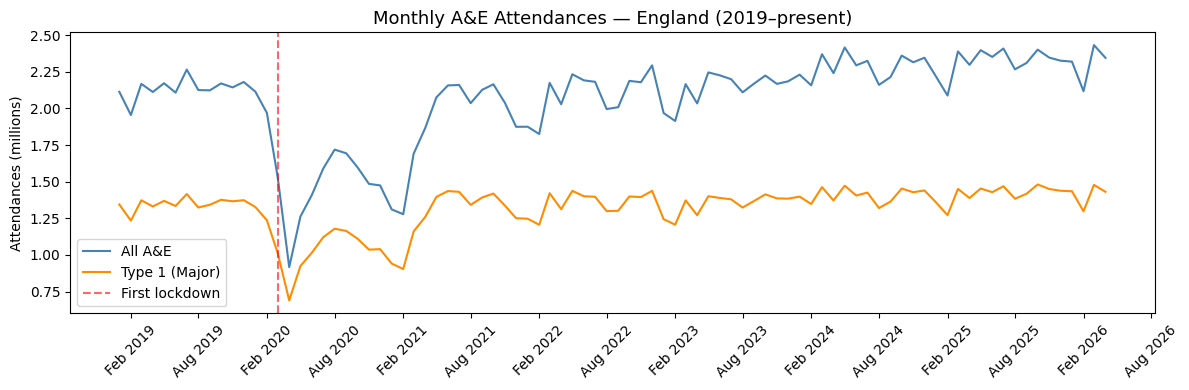

Saved to outputs/figures/


In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Quick load — just the columns we need
ts = pd.read_excel(
    TS_PATH,
    sheet_name="Activity",
    engine="xlrd",
    skiprows=13,
    usecols=["Period", "Total Attendances", "Type 1 Departments - Major A&E"]
).dropna(subset=["Period"])

# Filter to 2019 onwards for clarity
ts = ts[ts["Period"] >= "2019-01-01"].copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts["Period"], ts["Total Attendances"] / 1e6, label="All A&E", color="steelblue")
ax.plot(ts["Period"], ts["Type 1 Departments - Major A&E"] / 1e6, label="Type 1 (Major)", color="darkorange")
ax.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--", alpha=0.6, label="First lockdown")
ax.set_title("Monthly A&E Attendances — England (2019–present)", fontsize=13)
ax.set_ylabel("Attendances (millions)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/01_attendance_sanity_check.png", dpi=150)
plt.show()
print("Saved to outputs/figures/")

---
## Summary of Issues to Fix in Notebook 02

### Time Series (`Activity` sheet)
- [ ] Drop junk columns: `Unnamed: 0`, `Unnamed: 14`, `Unnamed: 16`, `0.95`
- [ ] Rename columns to short snake_case names
- [ ] Filter to April 2019 onwards (our analysis window)
- [ ] Export to `data/processed/national_monthly.csv`

### Time Series (`Performance` sheet)
- [ ] Same column cleanup
- [ ] Merge or keep separate from Activity — decide in notebook 02

### Quarterly By-Provider (all 24 files)
- [ ] Drop junk columns: `Unnamed: 0`, `Unnamed: 28` (rename last col to `icb_name` first)
- [ ] Rename disambiguated columns (`.1`, `.2` suffixes → meaningful names)
- [ ] Drop England total row (`Code == '-'`) and blank rows
- [ ] Add `year` and `quarter` columns derived from filename
- [ ] Coerce percentage columns to float (handle `-` values → NaN)
- [ ] Concatenate all 24 files into one DataFrame
- [ ] Export to `data/processed/quarterly_by_provider.csv`